## Overdamped Langevin SDE examples

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
import scipy as sp
import time
import sys
sys.path.append("/home/s2421480/Documents/PhD_first_year/Extended_summer_project/Codes/d3s/")
import ranndy_jax
import plotter
from plotter import *
import importlib
importlib.reload(ranndy_jax)
importlib.reload(plotter)
from ranndy_jax import RaNNDy, VAMPNets
import d3s.domain as domain
import d3s.algorithms as algorithms
import d3s.observables as observables
#import deeptime as dt
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'         
plt.rcParams['font.serif'] = ['Computer Modern Serif'] 
plt.ion()

## Data

In [34]:
# experiment = 'ou'   # Available 'tw2d', 'ou'

# # define domain
# bounds = np.array([[-2, 2]])  # Bounds for the domain    # TODO: remove one dimension from boxes and bounds for the OU process
# boxes = np.array([100])
# Omega = domain.discretization(bounds, boxes)


# if experiment == 'ou' or experiment == 'ls2d':
#     ## Load one long trajectory data from d3s (for the OU process and lemon-slice 2D)
#     data = sp.io.loadmat(f'/home/s2421480/Documents/PhD_third_year/rnn_closed_notebooks/data/{experiment}_data.mat')  #TODO: Change the path here ou
#     x = data[f'{experiment}_data']
#     X = x[:, :-1]
#     Y = x[:, 1:]

    
# if experiment == 'tw2d':
#     # data from deeptime (for triple-well 2D)
#     system = dt.data.triple_well_2d(h=1e-3, n_steps=500)
#     traj = system.trajectory(np.array([[0.1, 0.1]]), 20000, seed=42)
#     X = traj[:-1, :].T
#     Y = traj[1:, :].T

In [35]:
# ## Visualize data

# if experiment == 'ou':
#     plt.figure()
#     plt.hist(X.T, bins=500)
#     plt.show()
# else:
#     plt.figure()
#     plt.hist2d(X[0, :], X[1, :], bins=500)
#     plt.show()


## RaNNDy

In [54]:
## Run this cell to apply RaNNDy for the Koopman operator

operator = 'koopman'
hidden_sizes = [256, 512, 256]  # Hidden layer sizes
final_size = 5  # Output layer size
activation = "tanh"  # activation function
init_weights = 'lecun_normal'
init_bias = 'normal'  # Initialization of weights and biases
init_weights_std = 1.0  # Standard deviation for normal initialization
init_bias_std = 0.1  # Scale for uniform initialization
# direct_link=False  # Whether to use direct link to input # TODO:
random_state = 0  # Random state for reproducibility
n_eigfuncs = final_size  # Number of eigenfunctions to compute
kwargs = {} # only needed for Hamiltonian operator

ranndy = RaNNDy(
    X=X,
    operator=operator,
    hidden_sizes=hidden_sizes,
    final_size=final_size,
    activation=activation,
    init_weights_dist=init_weights, 
    init_weights_std=init_weights_std,
    init_bias_dist=init_bias,
    init_bias_std=init_bias_std,
    #direct_link=direct_link,
    random_state=random_state,
)

start_time = time.time()  # Start time for RNN eigendecomposition
# eigvals and eigenvectors approximation
Kr, eigvals_rnn, eigvecs_rnn = ranndy.operator_eig_decomp(
    X=X,
    Y=Y,
    Z=None,
    params=None,
    n=n_eigfuncs,
    epsilon=1e-5,
    kwargs=kwargs)

end_time = time.time()  # End time for RNN eigendecomposition
time_rnn = end_time - start_time
print(f"RNN eigendecomposition time: {time_rnn:.2f} seconds")

RNN eigendecomposition time: 0.87 seconds


In [55]:
eigvals_rnn

Array([0.9999955+0.j, 0.9984284+0.j, 0.9974263+0.j, 0.9947478+0.j,
       0.9940544+0.j], dtype=complex64)

In [56]:
print('eigvals and sum their sum', np.log(eigvals_rnn) / dt, np.sum(eigvals_rnn))
print('Trace of A: ', np.trace(Kr))

eigvals and sum their sum [-4.4703581e-03+0.j -1.5728317e+00+0.j -2.5770462e+00+0.j
 -5.2660236e+00+0.j -5.9633679e+00+0.j] (4.9846525+0j)
Trace of A:  4.9846516


## VAMPnets

In [62]:
## Run this cell to apply VAMPnets for Koopman operator

vampnet = VAMPNets(X=X, 
                   hidden_sizes=[256, 512, 256],
                   final_size=5,
                   activation='tanh',
                   init_weights_dist='normal', 
                   init_weights_std=init_weights_std,
                   init_bias_dist='zeros',
                   init_bias_std=init_bias_std,
                   #randomized=False,
                   batch_norm=False,
                   random_state=random_state, vampnet=True)

## Operator eigendecomposition using VAMPNet

epochs = [20, 40, 60, 80]  # Number of epochs for training
traces_vampnet = []
run_times = []

lr = 1e-2  # Learning rate for the optimizer; large lr leads to nan values so keep it small
optim = 'adam'  # Optimizer for training VAMPNet

for epoch in epochs:
   start_time = time.time()  # Start time for VAMPNet eigendecomposition

   params, loss = vampnet.training(X=X, Y=Y, n=n_eigfuncs, epochs=epoch, optim=optim, lr=lr, epsilon=1e-5)

   end_time = time.time()  # End time for VAMPNet eigendecomposition
   time_vampnet = end_time - start_time
   run_times.append(time_vampnet)
   traces_vampnet.append(loss[-1])
   print(f"VAMPNet eigendecomposition time: {time_vampnet:.2f} seconds")

## eigenfunctions using VAMPNet

Kv, eigvals_vampnet, eigvecs_vampnet = vampnet.koopman_approximation(params=params,
    X=X,
    Y=Y, n=n_eigfuncs)

Epoch 0, Loss: -4.7103
Epoch 10, Loss: -4.8254
VAMPNet eigendecomposition time: 78.24 seconds
Epoch 0, Loss: -4.6763


KeyboardInterrupt: 

## Plotting

In [6]:
plots = plotter.PlottingResults(X=X, bounds=bounds, boxes=boxes, n_eigfuncs=n_eigfuncs, operator='koopman')

/home/s2421480/Documents/Github_projects/ranndy/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/s2421480/Documents/Github_projects/ranndy/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


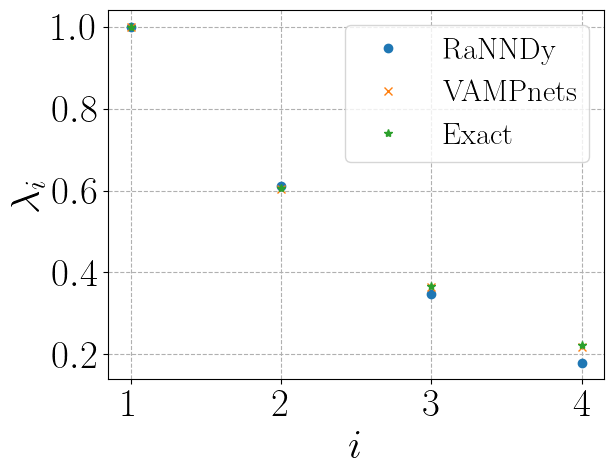

In [32]:
# plotting eigenvalues
plt.figure()
xv = np.arange(1, n_eigfuncs, 1)
plt.plot(xv, eigvals_rnn[:4], 'o', label='RaNNDy')
plt.plot(xv, eigvals_vampnet[:4], "x", label='VAMPnets')
if experiment == 'ou':
    plt.plot(xv, plotter.exact_eigv[:4], "*", label='Exact')
plt.grid(which="minor", linestyle=":")
plt.grid(which="major", linestyle="--")
plt.xlabel(r"$i$", fontsize=30)
plt.ylabel(r"$\lambda_i$", fontsize=30)
plt.legend(fontsize=22, loc='best')
plt.xticks(np.arange(1, 5, 1), fontsize=28)
plt.yticks(np.arange(0.2, 1.1, 0.2), fontsize=28)
plt.show()


In [22]:
## eigfunctions calculation

if experiment == 'ou':
        domain_eigf = Omega.midpointGrid()
else:
        domain_eigf = X


eigfuncs_rnn = ranndy.eigenfunctions(
        eigvecs=eigvecs_rnn,
        domain=domain_eigf,
        )

eigfuncs_vampnet = vampnet.eigenfunctions(params=params,
eigvecs=eigvecs_vampnet.T,
domain=domain_eigf,
)

if experiment =='ou':
        true_eigf_ou, eigfuncs_vampnet, eigfuncs_rnn = make_eigf_same_sign(domain_eigf=domain_eigf, eigf1=eigfuncs_vampnet, eigf2=eigfuncs_rnn)

        kwargs = {"eigf_vampnets": eigfuncs_vampnet, "eigf_exact": true_eigf_ou}

In [32]:
## plot ith eigenfunction (for OU process)

# fig, ax = plots.plot_eigenfunctions(eigfuncs=eigfuncs_rnn, num_funcs_to_plot=3, comparsion=True, **kwargs)

# plt.grid(which="minor", linestyle=":")
# plt.grid(which="major", linestyle="--")
# plt.xlabel(r"$x$", fontsize=30)
# #plt.ylabel("Eigenfunctions", fontsize=30)
# plt.legend(fontsize=20, loc='best')
# plt.xticks(np.arange(-2, 3, 1), fontsize=28)
# plt.yticks(np.arange(-1, 1.09, 0.4), fontsize=28)
# plt.show()

## Clustering eigenfunctions

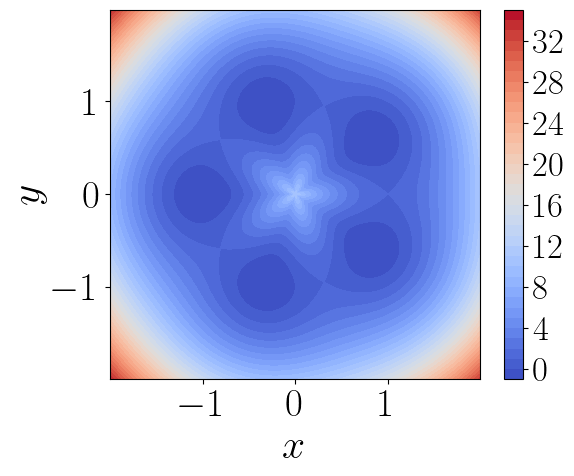

In [30]:
## Plot potential
system = 'lemon-slice'
fig, ax, con = plots.plot_potential(system=system)
ax.set_xlabel("$x$", fontsize=30)
ax.set_ylabel("$y$", fontsize=30)
ax.axis('square')
plt.xticks(np.arange(-1, 2, 1), fontsize=28)
plt.yticks(np.arange(-1, 2, 1), fontsize=28)
#ax.tick_params(axis="both", which="major", labelsize=28)
cbar = plt.colorbar(con, shrink=1.0)
#cbar.set_ticks(np.arange(-4, 10, 2))
cbar.ax.tick_params(labelsize=25)

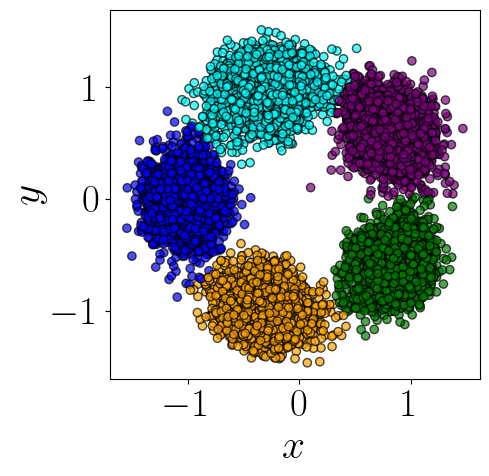

In [ ]:
## Clustering 5 dominant eigenfunctions

fig, ax = plots.cluster_eigenfunctions(eigfuncs=eigfuncs_rnn, n_eigfuncs=5, n_clusters=5, grid='data')
ax.set_xlabel('$x$', fontsize=30)
ax.set_ylabel('$y$', fontsize=30)
ax.axis('square')
plt.xticks(np.arange(-1, 2, 1), fontsize=28)
plt.yticks(np.arange(-1, 2, 1), fontsize=28)
plt.show()

## Ensemble Learning

In [ ]:
###TODO: For triple-well 2D

n_models = 100  # Number of models to ensemble
domain_eigf = Omega.midpointGrid()
n_eigfuncs = 5
ensem_ranndy = RaNNDy(
    X=domain_eigf,
    operator='koopman',
    hidden_sizes=[256, 512, 256],
    final_size=16,
    activation='tanh',
    init_weights_dist='lecun_normal', 
    init_weights_std=1.0,
    init_bias_dist='normal',
    init_bias_std=1.0,
    #direct_link=direct_link,
    random_state=0,
    vampnet=False
)
start_time = time.time()
(avg_eigvals, avg_eigfuncs, eigvals_plus, eigvals_minus, eigfuncs_plus, eigfuncs_minus) = ensem_ranndy.ensemble_models(n_models=n_models, X=X, Y=Y, Z=None, domain=domain_eigf, n=n_eigfuncs, epsilon=1e-5)
end_time = time.time()
ensem_time = end_time - start_time
print(f'time for {n_models} ensemble models: ', ensem_time)

/home/s2421480/Documents/PhD_third_year/rnn_closed_notebooks/experiments/algorithms_jax.py:652: ComplexWarning: Casting complex values to real discards the imaginary part
  ensem_eigvals[:, i] = eigvals
/home/s2421480/Documents/PhD_third_year/rnn_closed_notebooks/experiments/algorithms_jax.py:654: ComplexWarning: Casting complex values to real discards the imaginary part
  ensem_eigfuncs[:, :, i] = eigfuncs


time for 100 ensemble models:  46.3693790435791


In [4]:

plots = PlottingResults(X=X, bounds=bounds, boxes=boxes, n_eigfuncs=n_eigfuncs, operator='koopman')

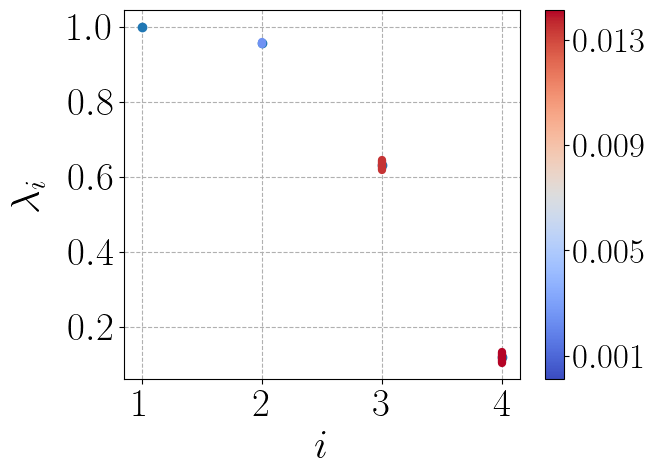

In [ ]:
fig, ax, cbar = plots.plot_eigenvalues_uncertainty(eigvals=avg_eigvals[:4], num_eigvals_to_plot=4, eigvals_plus=eigvals_plus[:4], eigvals_minus=eigvals_minus[:4])
#xv = np.arange(1, n_eigfuncs, 1)
#plt.plot(xv, eigvals_rnn[:4], 'o', label='RaNNDy')
#plt.plot(xv, eigvals_vampnet[:4], "x", label='VAMPnets')
#plt.plot(xv, exact_eigv[:4], "*", label='Exact')
plt.grid(which="minor", linestyle=":")
plt.grid(which="major", linestyle="--")
plt.xlabel(r"$i$", fontsize=30)
plt.ylabel(r"$\lambda_i$", fontsize=30, labelpad=15)
#plt.legend(fontsize=18, loc='best')
plt.xticks(np.arange(1, 5, 1), fontsize=28)
plt.yticks(np.arange(0.2, 1.1, 0.2), fontsize=28)
cbar.set_ticks(np.arange(0.001, 0.016, 0.004))
cbar.ax.tick_params(labelsize=25)
#cbar.set_label(r"Uncertainty (mean $\pm$ variance)", fontsize=19)
#plt.savefig("/home/s2421480/Documents/PhD_third_year/rnn_closed_notebooks/figures/tw2d_eigvals_uncer.pdf", bbox_inches="tight",dpi=300)
plt.show()

In [ ]:
# plot ith eigenfunction uncertainty

fig, ax = plots.plot_eigenfunctions_uncertainty(avg_eigfuncs=avg_eigfuncs, eigfuncs_plus=eigfuncs_plus, eigfuncs_minus=eigfuncs_minus, num_funcs_to_plot=1, trend=True, mode="3D")
ax.tick_params(labelsize=22)
ax.set_xlabel(r'$x$', fontsize=24)
ax.set_ylabel(r'$y$', fontsize=24)
#ax.set_zlabel(r'$z$', fontsize=20)


Text(0.5, 0.5, '$y$')

In [27]:
%matplotlib qt5

In [ ]:
avg = np.real(avg_eigfuncs[1, :])
plus = np.real(eigfuncs_plus[1, :])
minus = np.real(eigfuncs_minus[1, :])

norm1 = np.amax(np.abs(avg))
avg /= norm1

norm2 = np.amax(np.abs(minus))
minus /= norm2

norm3 = np.amax(np.abs(plus))
plus /= norm3

local_uncertainty = np.abs(plus - minus) / 2
local_uncertainty /= np.max(local_uncertainty)

norm = plt.Normalize(local_uncertainty.min(), local_uncertainty.max())
colors = cm.coolwarm(norm(local_uncertainty))
colors = colors.reshape(tuple(plots.boxes) + (4,))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
plots.plot(
    -avg,
    ax=ax,
    mode='3D',
    grid='midpoint',
    facecolors=colors,
    cmap='coolwarm'
)
ax.set_xlabel('$x$', fontsize=26, labelpad=10)
ax.set_ylabel('$y$', fontsize=26, labelpad=10)
plt.xticks(np.arange(-1, 2, 1), fontsize=24)
plt.yticks(np.arange(-1, 2, 1), fontsize=24)
ax.zaxis.set_ticks_position('lower')
ax.zaxis.set_label_position('lower')
# ax.zaxis._axinfo['juggled'] = (1, 1, 0)
ax.set_zticks(np.arange(-1, 1.1, 1))
ax.tick_params(axis='z', labelsize=22)  


cmap = cm.get_cmap("coolwarm")
mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array([np.arange(0, 1, 0.25)])  
cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=20, use_gridspec=True)
cbar.set_ticks(np.arange(0.1, 1.1, 0.2))
#cbar.set_label("Local Uncertainty", fontsize=24)
cbar.ax.tick_params(labelsize=24)
ax.view_init(elev=25, azim=-40, roll=-0)


/tmp/ipykernel_9375/3662690474.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("coolwarm")


In [ ]:
### Extras
# i = 4
# print(f'Sum of {i} dominant exact eigenvalues', np.sum(exact_eigv[:i]))
# print(f'Sum of {i} dominant eigenvalues using RaNNDy', np.sum(eigvals_rnn[:i]))
# print(f'Sum of {i} dominant eigenvalues using VAMPnets', np.sum(eigvals_vampnet[:i]))